## Introduction to Classification with TensorFlow

**What I'm going to cover**

1. Architecture of a neural network classification model
2. Input shapes and output shapes of a classification model(features and labels)
3. Creating custom data to view and fit
4. Steps in modelling
* Creating a model
* Compiling a model
* Fitting a model
* Evaluating a model
5. Different classification evaluation metrics
6. Saving and loading models

#### What is a classification?

A classification is where you try to classify someting as one thing or another.
A few types of classification problems:
* Binary classification
* Multi-class classification
* Multi-label classification

## Creating data to view and fit

In [ ]:
from sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [ ]:
# Check out the features
X

array([[ 0.74220688,  0.24668576],
       [-0.7340323 ,  0.16869164],
       [-0.82985872,  0.22195899],
       ...,
       [-0.12823057, -0.82613318],
       [ 0.66090453, -0.79319015],
       [ 0.27841491,  0.96735953]])

In [ ]:
# check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

The data is a little hard to understand, just visualize it

In [ ]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:,0], "X1":X[:,1], "label":y})
circles

,X0,X1,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0
...,...,...,...
995,0.249091,0.925787,0
996,-0.985370,-0.288162,0
997,-0.128231,-0.826133,1
998,0.660905,-0.793190,0


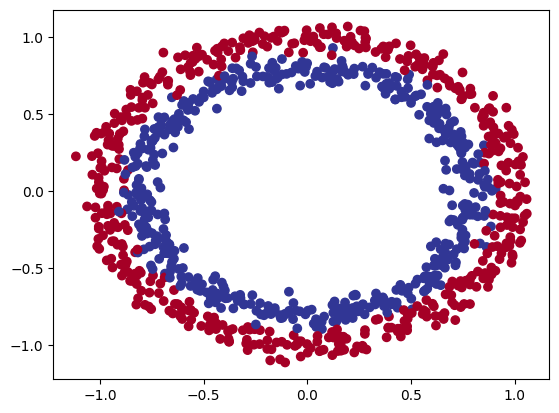

In [ ]:
# Visuallize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

## Input and output shapes

In [ ]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [ ]:
# Check how many samples we're working with
len(X), len(y)

(1000, 1000)

In [ ]:
# View the first example of features and labels
X[0], y[0]

(array([0.74220688, 0.24668576]), np.int64(1))

# Steps in modelling

The steps in modelling wit TensorFlow are typically

1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate....

In [ ]:
#set the random seed
import tensorflow as tf
tf.random.set_seed(42)

# Create the model using the sequential Api
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["Accuracy"])

# Fit the model
model_1.fit(X, y, epochs=5)



Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.4850 - loss: 6.3356
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4560 - loss: 5.4054 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4400 - loss: 5.4364 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4600 - loss: 4.7658 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4830 - loss: 3.0201 


Not working, the model is guessing, Try to train it for longer

In [ ]:
#set the random seed
import tensorflow as tf
tf.random.set_seed(42)

# Create the model using the sequential Api
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["Accuracy"])

# Fit the model
model_1.fit(X, y, epochs=200)


Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.4800 - loss: 6.2105
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4960 - loss: 5.8837 
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5540 - loss: 4.9685 
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5290 - loss: 4.6269 
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5200 - loss: 4.3865 
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5200 - loss: 4.2197 
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.5460 - loss: 5.0901
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5280 - loss: 4.4506 
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5260 - loss: 4.2637 
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.5210 - loss: 3.8100 
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4900 - loss: 7.4368 
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

Since we're working on a binary classification and our model is getting 50% accuracy. The modle is guessing
Try adding extra layers to the hidden layers


In [ ]:
# Set random see
tf.random.set_seed(42)

# Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["Accuracy"])

# Fit the model
model_2.fit(X, y, epochs=200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.4710 - loss: 0.9115
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.4840 - loss: 0.6981
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.4820 - loss: 0.6955
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.4870 - loss: 0.6946
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.4760 - loss: 0.6943
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.4750 - loss: 0.6942
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.4760 - loss: 0.6941
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.4600 - loss: 0.6940
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4700 - loss: 0.6940 
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4600 - loss: 0.6940 
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4660 - loss: 0.6940 
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accura

In [ ]:
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4700 - loss: 0.6932  


[0.693231463432312, 0.4699999988079071]

## Improving a model
1. Try increase the number of hidden  units within a layer
2. Choosing a differen optimization function
3. Leave it training for longer

In [ ]:
# Create model 3 with the above improvements
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["Accuracy"])

# 3. Fit the model
model_3.fit(X,y, epochs= 100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.4630 - loss: 1.0276
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4730 - loss: 0.7006  
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4650 - loss: 0.7004
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4640 - loss: 0.7004
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4630 - loss: 0.7004
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4630 - loss: 0.7003
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4630 - loss: 0.7003
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4620 - loss: 0.7003
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4620 - loss: 0.7003
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.4620 - loss: 0.7002
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.4620 - loss: 0.7002
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accurac

In [ ]:
model_3.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.4860 - loss: 0.6943  


[0.6943185329437256, 0.4860000014305115]

**Note:** Even with the new changes the model is still guessing,

**How to fix it?**

* Change the activation functions in the hidden layers
* Change the optimization fuction to Adam()
* Include a learning rate in the optimizer
* Fit the  model for longer maybe 500 epochs

In [ ]:
tf.random.set_seed(42)

# Create model_4
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["Accuracy"])

# Fit the model
history_1 = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Accuracy: 0.5230 - loss: 0.6916
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.5930 - loss: 0.6641
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.7080 - loss: 0.5968
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8890 - loss: 0.4197
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9400 - loss: 0.2468
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9600 - loss: 0.1611
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9590 - loss: 0.1241
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9610 - loss: 0.1074
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9610 - loss: 0.0994
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.9610 - loss: 0.0946
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.9640 - loss: 0.0911
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy:

In [ ]:
model_4.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.9710 - loss: 0.0799


[0.07989150285720825, 0.9710000157356262]

### The machine learning engineer's code is visualize visualize visualize

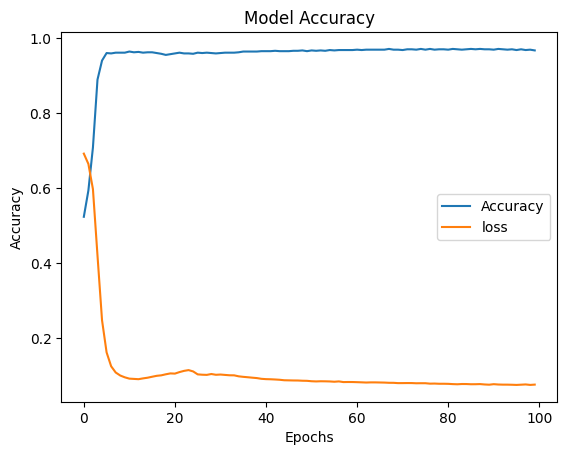

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Plot only the accuracy columns
pd.DataFrame(history_1.history)[['Accuracy', 'loss']].plot()

# 2. Add the correct labels
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.show()

To Visualize the model's predictions....

Create a fucntion `plot_decision_boundary()`, this function will:

* Take in a trained model, feature(X) and labels(y)
* Create a meshgrid of the different X values
* Make prediction across the meshgrid
* Plot the prediction a weel as a line between zones(where each unique class falls)

In [ ]:
import numpy as np

def plot_decision_boundary(model, X, y):
  """
  Plots the decision boundary created by a model predicting on X.
  """

  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() -0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() -0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X value (to make prediciton on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(x_in)

  # Check for multi-class
  if len(y_pred[0]) > 1:
    print("Doing multiclass classification")
    # We have to reshape our predictions
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("Doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


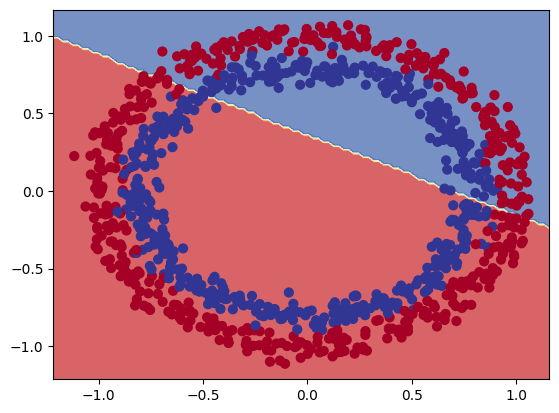

In [ ]:
# Check out the predictions our model is making
plot_decision_boundary(model_3, X, y)

### Can the model_3 be used for a regression problem?

In [ ]:
tf.random.set_seed(42)

# Create some regression data
X_regression = tf.range(0, 1000, 5)
y_regression = tf.range(100,1100,5)

# Split the regression into training and test sets
X_reg_train = X_regression[:150]
X_reg_test = X_regression[150:]
y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

# Fit our model to our regression data
model_3.fit(X_reg_train, y_reg_train, epochs=100)

Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_3_1/Cast:0", shape=(None,), dtype=float32) with name 'keras_tensor_7' and path ''. Expected shape (None, 2), but input has incompatible shape (None,)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None,), dtype=int32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Oh wait .... We compiled our model for binary classification problem

But we're now working or a regression problem, let's change the model to suit our data

In [ ]:
X_reg_train = tf.expand_dims(X_reg_train, axis=1)
X_reg_train

<tf.Tensor: shape=(150, 1), dtype=int32, numpy=
array([[  0],
       [  5],
       [ 10],
       [ 15],
       [ 20],
       [ 25],
       [ 30],
       [ 35],
       [ 40],
       [ 45],
       [ 50],
       [ 55],
       [ 60],
       [ 65],
       [ 70],
       [ 75],
       [ 80],
       [ 85],
       [ 90],
       [ 95],
       [100],
       [105],
       [110],
       [115],
       [120],
       [125],
       [130],
       [135],
       [140],
       [145],
       [150],
       [155],
       [160],
       [165],
       [170],
       [175],
       [180],
       [185],
       [190],
       [195],
       [200],
       [205],
       [210],
       [215],
       [220],
       [225],
       [230],
       [235],
       [240],
       [245],
       [250],
       [255],
       [260],
       [265],
       [270],
       [275],
       [280],
       [285],
       [290],
       [295],
       [300],
       [305],
       [310],
       [315],
       [320],
       [325],
       [330],
       [335],


In [ ]:
# Set up random seed
tf.random.set_seed(42)

# Create  a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])


# Compile the model
model_3.compile(loss=tf.keras.losses.mae,
           optimizer=tf.keras.optimizers.Adam(),
           metrics=["mae"])

# Fit the model
model_3.fit(X_reg_train, y_reg_train, epochs=100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 458.0730 - mae: 458.0730
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 339.6970 - mae: 339.6970 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 219.5976 - mae: 219.5976 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 96.4153 - mae: 96.4153   
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 60.8274 - mae: 60.8274 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 85.2009 - mae: 85.2009 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 63.1561 - mae: 63.1561 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.7142 - mae: 45.7142 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 50.3984 - mae: 50.3984 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 42.5620 - mae: 42.5620
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 44.7526 - mae: 44.7526 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 41.6249 - mae: 41.6249 
Epoch 13/100
5/5 ━

In [ ]:
X_reg_train.ndim, y_reg_train.ndim

(2, 1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


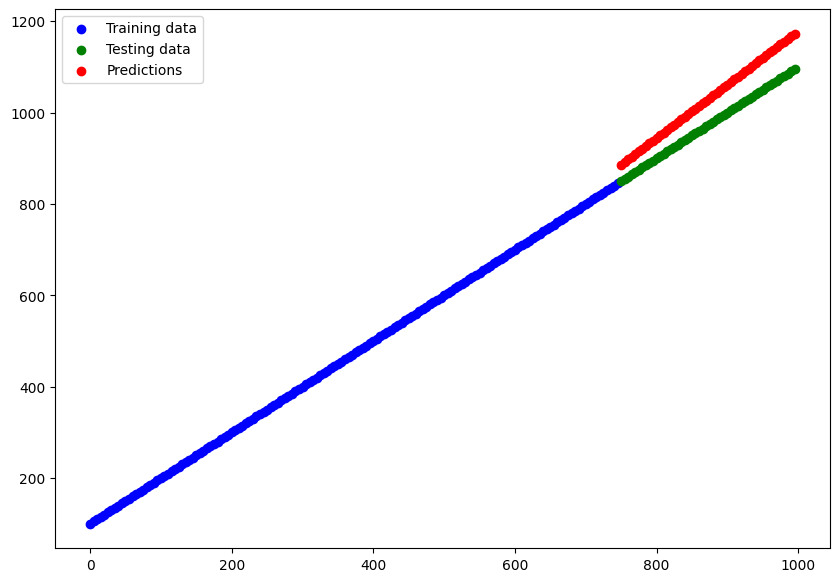

In [ ]:
# Make prediction with our trained model
y_reg_preds = model_3.predict(X_reg_test)

# Plot the model's predictions against our regression data
plt.figure(figsize=(10,7))
plt.scatter(X_reg_train, y_reg_train, c="b", label="Training data")
plt.scatter(X_reg_test, y_reg_test, c="g", label="Testing data")
plt.scatter(X_reg_test, y_reg_preds, c='r', label= "Predictions")
plt.legend()

## Non-Linearity

Going back to model_4,
This model achieved a greater accuracy value and was able to predict the data better. It wans'nt guessing

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


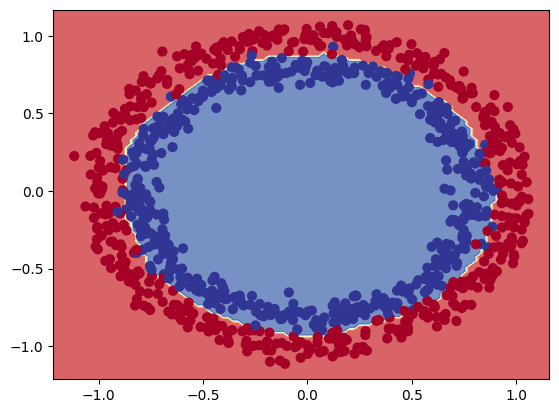

In [ ]:
# Check out the predictions our model is making
plot_decision_boundary(model_4, X, y)

### The missing piece: Non-Linerity

In [ ]:
# Set the random seed
tf.random.set_seed(42)

# Create the model
modle_4=tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# Compile the modle
model_4.compile(loss='binary_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=["accuracy"])

# Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9710 - loss: 0.0658
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9790 - loss: 0.0569
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9790 - loss: 0.0567
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.0562
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9800 - loss: 0.0559
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.0557
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.0555
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9790 - loss: 0.0553
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9800 - loss: 0.0552
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9810 - loss: 0.0550
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9810 - loss: 0.0549
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

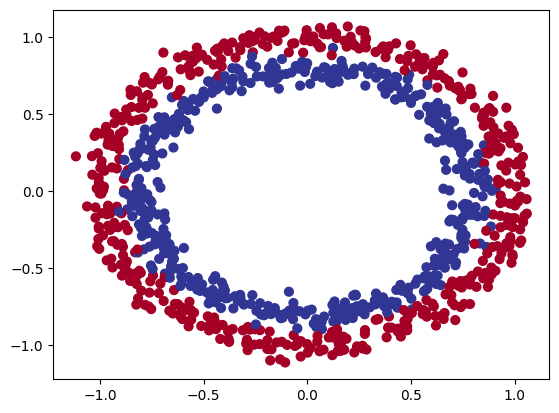

In [ ]:
# Check the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Doing binary classification


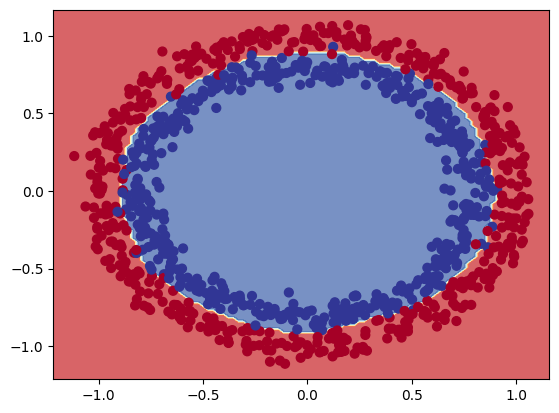

In [ ]:
# Check the decision boundary for our latest boundary
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non  linear
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# Compile the model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# Fit the model
history_1 = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4300 - loss: 4.5057   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4170 - loss: 4.3910
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4210 - loss: 4.2481 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4360 - loss: 4.1971 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4360 - loss: 4.1548 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4350 - loss: 4.0960 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4430 - loss: 4.0656
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4430 - loss: 4.0358
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4480 - loss: 3.9866 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4500 - loss: 3.9307
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4530 - loss: 3.9102
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - a

In [ ]:
X = tf.expand_dims(X, axis=-1)
X

<tf.Tensor: shape=(1000, 2, 1), dtype=float64, numpy=
array([[[ 0.74220688],
        [ 0.24668576]],

       [[-0.7340323 ],
        [ 0.16869164]],

       [[-0.82985872],
        [ 0.22195899]],

       ...,

       [[-0.12823057],
        [-0.82613318]],

       [[ 0.66090453],
        [-0.79319015]],

       [[ 0.27841491],
        [ 0.96735953]]])>

In [ ]:
X.shape

TensorShape([1000, 2, 1])

In [ ]:
y.shape

(1000,)

In [ ]:
X=tf.squeeze(X)
X.shape

y = tf.expand_dims(y, axis=-1)
y.shape

y.shape, X.shape


(TensorShape([1000, 1]), TensorShape([1000, 2]))

In [ ]:
X=tf.squeeze(X)
y=tf.squeeze(y)

X.shape, y.shape

(TensorShape([1000, 2]), TensorShape([1000]))

In [ ]:
# Time to replicate the multilayer neural network from TensorFlow playgoudn

# set the random seed
tf.random.set_seed(42)

# Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_6.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=["accuracy"])

# Fit the model
history_2 = model_6.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5090 - loss: 0.6940
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5380 - loss: 0.6906
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5190 - loss: 0.6883
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5230 - loss: 0.6864
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5230 - loss: 0.6849
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5250 - loss: 0.6836
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5290 - loss: 0.6826
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5320 - loss: 0.6817
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5300 - loss: 0.6809
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5270 - loss: 0.6802
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5260 - loss: 0.6796
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [ ]:
model_6.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9300 - loss: 0.3366  


[0.33660688996315, 0.9300000071525574]

In [ ]:
# Visualize  the prediction
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'min'

In [ ]:
# Set the random seed
tf.random.set_seed(42)


# 1. Create a model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

# 2. Compile the model
model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history_3 = model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4980 - loss: 0.6969
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5040 - loss: 0.6954
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.6944
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.6934
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5120 - loss: 0.6925
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5140 - loss: 0.6916
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5050 - loss: 0.6908
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5100 - loss: 0.6898
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5120 - loss: 0.6889
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5110 - loss: 0.6878
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5150 - loss: 0.6874
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [ ]:
# Evaluate the model
model_7.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7840 - loss: 0.5590


[0.5589567422866821, 0.7839999794960022]

**Correction**

I realized that i was getting errors for model_6  because i was using tensors since i had previously used `tf.squeeze` on X and y.

The error attribute .min is not found is because the X and y values were in tensor form. Using .numpy() converts them back to intergers

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Doing binary classification


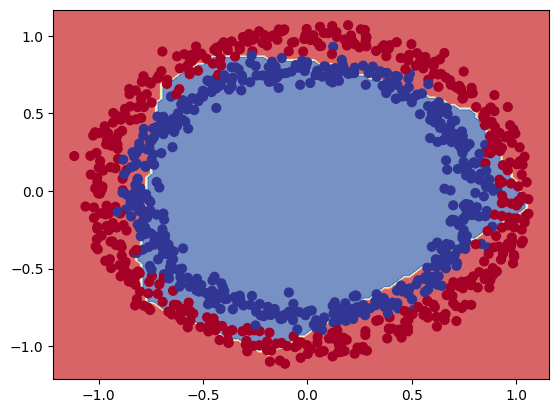

In [ ]:
# Visualize the metrics
plot_decision_boundary(model_7, X=X.numpy(), y=y.numpy())

The problem with the above evaluation is than the data used to train the model is the same one used to predit the  perfomance of the model.

Getting an accuracy of 90% is more of Generalization rather than actually learning and making patterns for unseen data

In [ ]:
# Create  a toy tensor(similar to the data passed to the model)

A = tf.cast(tf.range(-10,10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

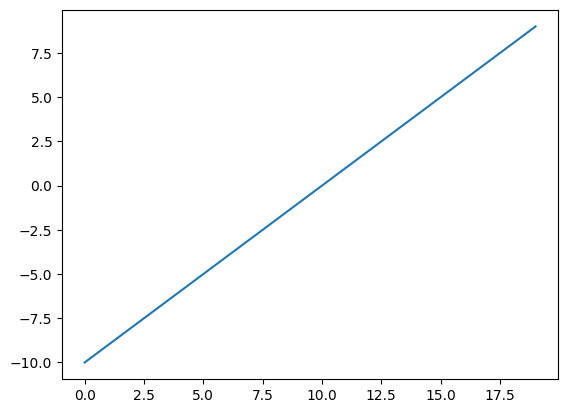

In [ ]:
# Visualize the toy tensor
plt.plot(A)

In [ ]:
# Let's start by replicating sigmoid - sigmoid(X) = 1 / (1 + exp(-1))
def sigmoid(x):
  return 1 / (1+tf.exp(-x))

# use the sigmoid funftion on our toy tensro
sigmoid(A)


<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

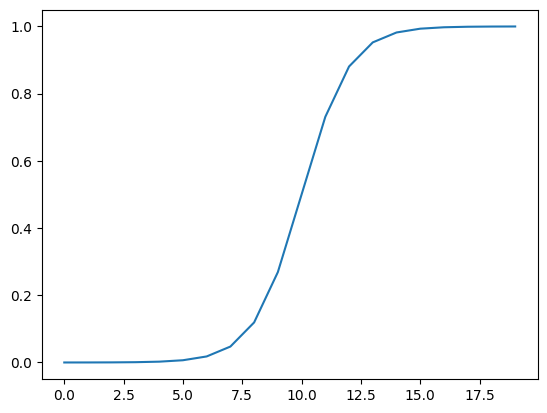

In [ ]:
# Plot out toy tensor
plt.plot(sigmoid(A));

In [ ]:
# Recreating the RELu function
def relu(x):
  return tf.maximum(0, x)

# pass our toy tensor to our custom relue function
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

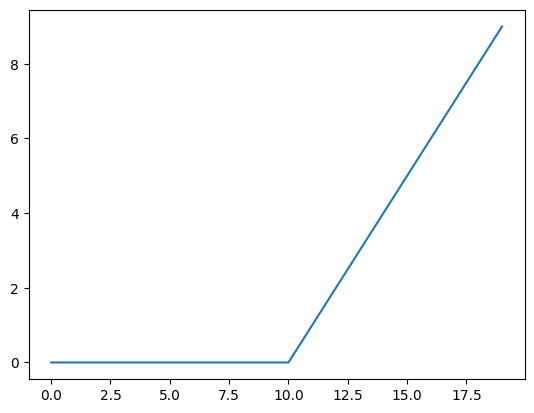

In [ ]:
# plot relu
plt.plot(relu(A));

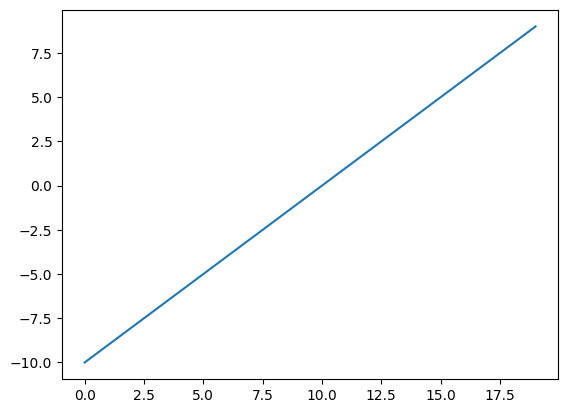

In [ ]:
plt.plot(A)

In [ ]:
# Let' try the linear activation function
linear_A = tf.keras.activations.linear(A)
linear_A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

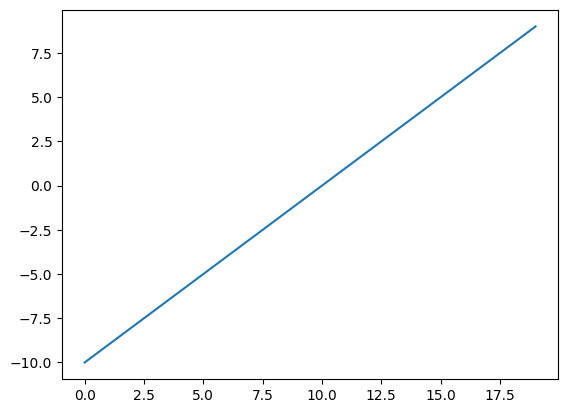

In [ ]:
plt.plot(linear_A);

In [ ]:
# Does A even change
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

## Evaluating and Improving the classification

So far , I've been training and testing on the same dataset.

However, n machine learning this is basically a sin
Sot let's create training and test set

In [ ]:
# Split into train and test sets
X_train, y_train = X[:800] , y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(TensorShape([800, 2]),
 TensorShape([200, 2]),
 TensorShape([800]),
 TensorShape([200]))

In [107]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model(same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


# 2. Compile the model
model_8.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

# Fit the model
history_4 = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4787 - loss: 0.6955
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4975 - loss: 0.6919
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5075 - loss: 0.6905  
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5225 - loss: 0.6886 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5200 - loss: 0.6861 
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5350 - loss: 0.6827 
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5875 - loss: 0.6781 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6288 - loss: 0.6695 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6550 - loss: 0.6453 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7412 - loss: 0.6004 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8050 - loss: 0.5386 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0

In [ ]:
model_8.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9600 - loss: 0.1371 


[0.13714997470378876, 0.9599999785423279]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Doing binary classification


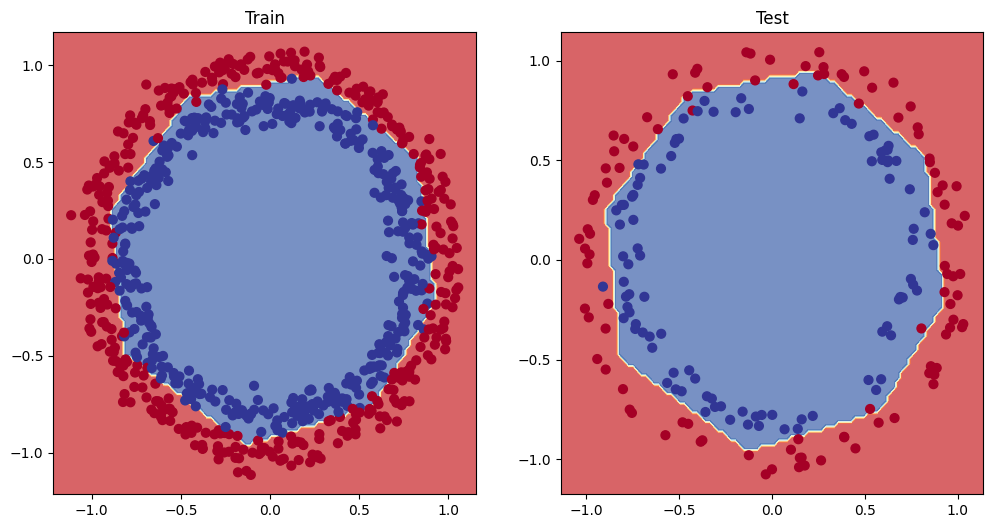

In [ ]:
# Visualize the model


# Since i had already converted the intergers to tensors use numpy() to reverse
X_train=X_train.numpy()
y_train=y_train.numpy()
X_test = X_test.numpy()
y_test = y_test.numpy()
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X=X_test, y=y_test)

In [ ]:
import pandas as pd
pd.DataFrame(history_4.history)


,accuracy,loss
0,0.48625,0.696862
1,0.51625,0.685303
2,0.55500,0.676302
3,0.63750,0.661402
4,0.62500,0.640269
...,...,...
95,0.95875,0.086116
96,0.95875,0.086104
97,0.95875,0.086091
98,0.96000,0.086078


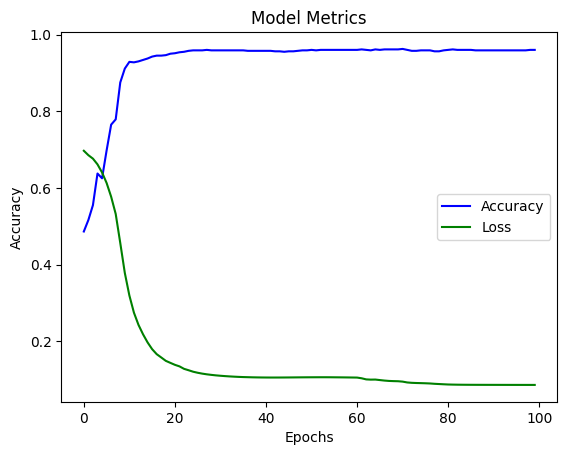

In [ ]:
# Pass the color argument outside the dictionary bracket selection
plt.plot(history_4.history['accuracy'], c="b", label="Accuracy")
plt.plot(history_4.history['loss'], c="g", label="Loss")
plt.title("Model Metrics")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Note:** For many problems, the loss function going down means the model is improving(the predictions its making are getting ground truth labels)

## Finding the best learning rate
To find the ideal learning rate(the learning rate where the loss decreases the most during training) we're going to use the following steps:

* A learning rate **callback** - Think of a callback as an extra piece of functionality that can be added to the model while in training

* Another model( Could probably use  the same as above but with different parameters)

* A modifird loss curve plot

In [ ]:
# Set random seed
tf.random.set_seed(42)

 # Create a model
model_9 = tf.keras.Sequential([
     tf.keras.layers.Dense(4, activation="relu"),
     tf.keras.layers.Dense(4, activation="relu"),
     tf.keras.layers.Dense(1, activation="sigmoid")
 ])

 # Compile the model
model_9.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=["accuracy"])

 # Create a learning rate callback
lr_schedular = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

 # Fit the model
history_5 = model_9.fit(X_train, y_train, epochs=100, callbacks=[lr_schedular])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4925 - loss: 0.6891 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4925 - loss: 0.6888 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4975 - loss: 0.6886 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4988 - loss: 0.6883 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4988 - loss: 0.6880 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4988 - loss: 0.6877 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4988 - loss: 0.6873 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5050 - loss: 0.6870 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5113 - loss: 0.6866 - learning_

In [ ]:
pd.DataFrame(history_5.history)

,accuracy,loss,learning_rate
0,0.49250,0.689116,0.000100
1,0.49250,0.688848,0.000112
2,0.49750,0.688576,0.000126
3,0.49875,0.688289,0.000141
4,0.49875,0.687985,0.000158
...,...,...,...
95,0.48875,0.798576,5.623413
96,0.48375,0.845378,6.309574
97,0.48625,0.892971,7.079458
98,0.48625,0.941539,7.943282


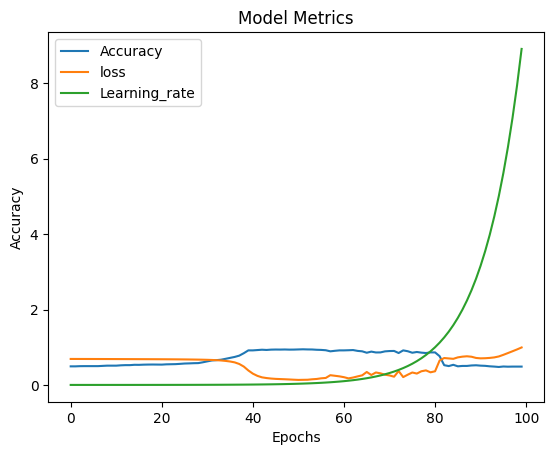

In [ ]:
# Visualize it
plt.plot(history_5.history['accuracy'], label="Accuracy")
plt.plot(history_5.history['loss'], label = "loss")
plt.plot(history_5.history['learning_rate'], label="Learning_rate")
plt.title("Model Metrics")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show();

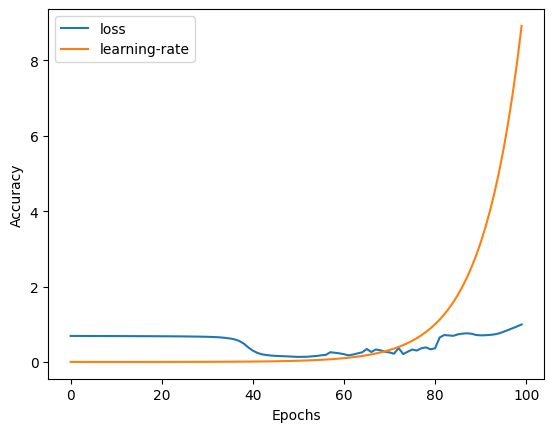

In [ ]:
  # Visualize the loss and the learning rate
  plt.plot(history_5.history['loss'], label='loss')
  plt.plot(history_5.history['learning_rate'], label='learning-rate')
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

### Why I'm thingking like a kienyeji, Remember I am a scientiest. A Data scientist

So the above plot is laughable. The correct way to do it is below

/tmp/ipykernel_4828/2343369920.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


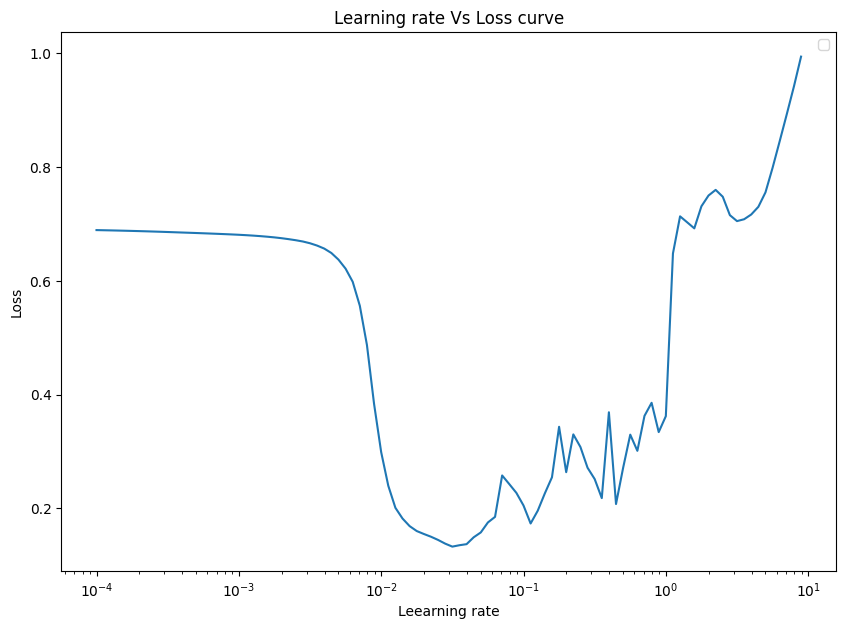

In [ ]:
# Plot the learning rate versus the loss
lrs = 1e-4 *( 10 ** (tf.range(100)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history_5.history['loss'])
plt.xlabel("Leearning rate")
plt.ylabel("Loss")
plt.title("Learning rate Vs Loss curve")
plt.legend()
plt.show()

## Finding the Ideal Learning rate

Ideally from the graph, you would choose the best learning rate a few clicks backs to the left from the lowest point on the curve

Pick the point where the learning rate vs loss curve drops sharpest

In [100]:
# Examples of other typical learning rates values:
10**00, 10**-1, 10**-2, 1e-4

(1, 0.1, 0.01, 0.0001)

In [110]:
# Try using a higher learning rate
tf.random.set_seed(42)

# Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_10.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                 metrics=['accuracy'])

# Fit the model
history_6 = model_10.fit(X_train, y_train, epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4775 - loss: 0.6969
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5188 - loss: 0.6932
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5350 - loss: 0.6928
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5375 - loss: 0.6918 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5763 - loss: 0.6875
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6237 - loss: 0.6751 
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7138 - loss: 0.6465 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7125 - loss: 0.5834 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7912 - loss: 0.5002 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8637 - loss: 0.4072 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8925 - loss: 0.3404 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.90

In [111]:
model_10.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8850 - loss: 0.2094  


[0.2094094157218933, 0.8849999904632568]

In [109]:
model_8.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9600 - loss: 0.1450 


[0.14496749639511108, 0.9599999785423279]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


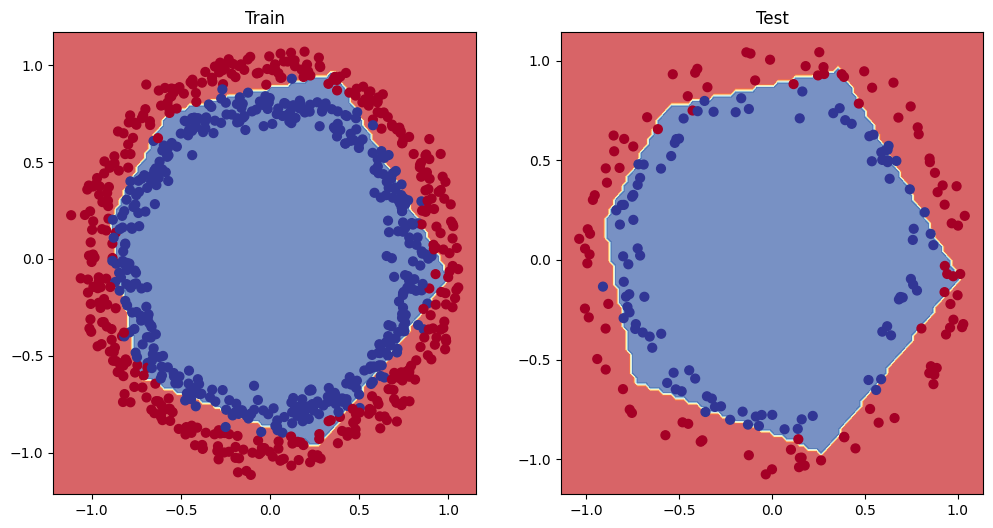

In [114]:
 # Plot the decision boundary for test sets
 plt.figure(figsize=(12,6))
 plt.subplot(1, 2, 1)
 plt.title("Train")
 plot_decision_boundary(model_10, X=X_train, y=y_train)
 plt.subplot(1, 2, 2)
 plt.title("Test")
 plot_decision_boundary(model_10, X=X_test, y=y_test)
 plt.show()